In [40]:
import os

print(os.listdir()) 

['.ipynb_checkpoints', 'atc_association_and_network.ipynb', 'ddi_target_overlap.png', 'drugbank data exploration.ipynb', 'README.md', 'y_get_network_notebook.ipynb']


In [62]:
import pickle
import random
import os

p_folder = "../data/atc_code_output/"

atc_files = [
    "who_atc_A.pkl","who_atc_B.pkl","who_atc_C.pkl","who_atc_D.pkl",
    "who_atc_G.pkl","who_atc_H.pkl","who_atc_J.pkl","who_atc_L.pkl",
    "who_atc_M.pkl","who_atc_N.pkl","who_atc_P.pkl","who_atc_R.pkl",
    "who_atc_S.pkl","who_atc_V.pkl"
]

the_level4 = []

for f in atc_files:

    path = os.path.join(p_folder,f)

    with open(path,"rb") as file:

        codes = pickle.load(file)

        level4 = [c for c in codes if len(c)==5] #level 4 (lenth 5)

        the_level4.extend(level4)

print("Total level4:",len(the_level4))

random_atc = random.sample(the_level4,20)

print("Random ATC classes:",random_atc)


def get_atc_path(code):

    level2 = code[:3] #first 3 
    level3 = code[:4] #first 4
    level4 = code #all

    return [level2,level3,level4]

Total level4: 939
Random ATC classes: ['A03CC', 'A03AA', 'A03CB', 'C07BA', 'G01AE', 'V09GA', 'D08AF', 'N01AB', 'V06DA', 'L01EF', 'V09DA', 'P02CB', 'N02CX', 'D01BA', 'L01EJ', 'N06CB', 'J05AB', 'D08AK', 'N05AG', 'N02CD']


In [63]:
import numpy as np

def tanimoto(a,b):

    a=set(a)
    b=set(b)

    return len(a&b)/len(a|b)

paths = {}

for code in random_atc:
    path = get_atc_path(code)
    paths[code] = path #code to list

print(paths)
print("Number of sampled ATC classes:", len(random_atc))
print("Sampled ATC classes:")
print(random_atc)
n=len(random_atc)

sim_matrix=np.zeros((n,n))

for i,c1 in enumerate(random_atc):
    for j,c2 in enumerate(random_atc):

        sim_matrix[i,j]=tanimoto(paths[c1],paths[c2])

sim_matrix



{'A03CC': ['A03', 'A03C', 'A03CC'], 'A03AA': ['A03', 'A03A', 'A03AA'], 'A03CB': ['A03', 'A03C', 'A03CB'], 'C07BA': ['C07', 'C07B', 'C07BA'], 'G01AE': ['G01', 'G01A', 'G01AE'], 'V09GA': ['V09', 'V09G', 'V09GA'], 'D08AF': ['D08', 'D08A', 'D08AF'], 'N01AB': ['N01', 'N01A', 'N01AB'], 'V06DA': ['V06', 'V06D', 'V06DA'], 'L01EF': ['L01', 'L01E', 'L01EF'], 'V09DA': ['V09', 'V09D', 'V09DA'], 'P02CB': ['P02', 'P02C', 'P02CB'], 'N02CX': ['N02', 'N02C', 'N02CX'], 'D01BA': ['D01', 'D01B', 'D01BA'], 'L01EJ': ['L01', 'L01E', 'L01EJ'], 'N06CB': ['N06', 'N06C', 'N06CB'], 'J05AB': ['J05', 'J05A', 'J05AB'], 'D08AK': ['D08', 'D08A', 'D08AK'], 'N05AG': ['N05', 'N05A', 'N05AG'], 'N02CD': ['N02', 'N02C', 'N02CD']}
Number of sampled ATC classes: 20
Sampled ATC classes:
['A03CC', 'A03AA', 'A03CB', 'C07BA', 'G01AE', 'V09GA', 'D08AF', 'N01AB', 'V06DA', 'L01EF', 'V09DA', 'P02CB', 'N02CX', 'D01BA', 'L01EJ', 'N06CB', 'J05AB', 'D08AK', 'N05AG', 'N02CD']


array([[1. , 0.2, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.2, 1. , 0.2, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.5, 0.2, 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0.2, 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0

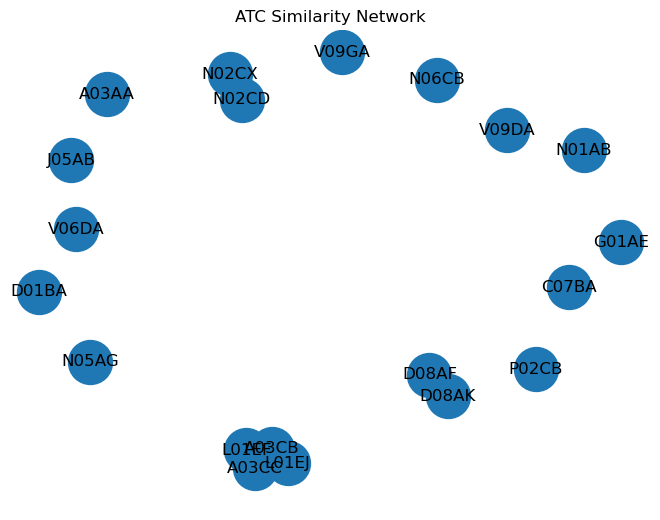

In [65]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

#  nodes 
for code in random_atc:
    G.add_node(code)

#  edges   
for i in range(n):
    for j in range(i+1, n):

        similarity = sim_matrix[i][j]

        if similarity > 0.2:
            G.add_edge(random_atc[i], random_atc[j], weight=similarity)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=1000)

plt.title("ATC Similarity Network")

plt.show()